In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

In [2]:
RANDOM_STATE = 42
DATA_DIR = "data"
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
LABELS_DIR = os.path.join(ARTIFACTS_DIR, "labels")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(LABELS_DIR, exist_ok=True)

DATASETS = [
    "S07-hw-dataset-01.csv",
    "S07-hw-dataset-02.csv",
    "S07-hw-dataset-03.csv"
]

METRICS_SUMMARY = {}
BEST_CONFIGS = {}

In [8]:
def load_data(filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)
    sample_id = df['sample_id']
    X = df.drop(columns=['sample_id'])
    return df, X, sample_id


def basic_eda(df, name):
    print(f"\n--- EDA: {name} ---")
    print(f"Shape: {df.shape}")
    print("Info:")
    print(df.info())
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nStatistics:")
    print(df.describe())
    print("\nHead:")
    print(df.head())


def get_preprocessor(X):
    numeric_features = X.select_dtypes(include=[np.number]).columns
    
    if X[numeric_features].isnull().sum().sum() == 0:
        transformer = Pipeline(steps=[
            ('scaler', StandardScaler())
        ])
    else:
        transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ])
    
    return transformer


def calculate_internal_metrics(X, labels):
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
    
    if n_clusters < 2:
        return {
            "silhouette": -1,
            "davies_bouldin": 100,
            "calinski_harabasz": 0
        }
    
    mask = labels != -1
    if np.sum(mask) < 2:
         return {
            "silhouette": -1,
            "davies_bouldin": 100, 
            "calinski_harabasz": 0
        }

    X_clean = X[mask]
    labels_clean = labels[mask]
    
    return {
        "silhouette": round(silhouette_score(X_clean, labels_clean), 3),
        "davies_bouldin": round(davies_bouldin_score(X_clean, labels_clean), 3),
        "calinski_harabasz": round(calinski_harabasz_score(X_clean, labels_clean), 1)
    }


def visualize_pca(X, labels, title, filename_suffix):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=15, alpha=0.7)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    
    save_path = os.path.join(FIGURES_DIR, f"pca_{filename_suffix}.png")
    plt.savefig(save_path)
    plt.show()


==================== PROCESSING S07-hw-dataset-01.csv ====================

--- EDA: S07-hw-dataset-01.csv ---
Shape: (12000, 9)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB
None
sample_id      int64
f01          float64
f02          float64
f03          float64
f04          float64
f05          float64
f06          float64
f07          float64
f08          float64
dtype: object

Missing values:
sample_id    0
f01          0
f02      

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745



Head:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213



--- S07-hw-dataset-01.csv: KMeans Experiment ---


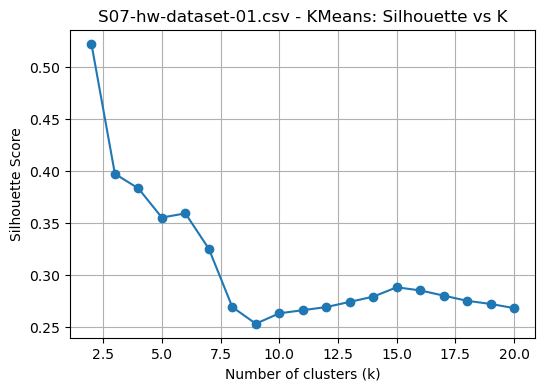

Best KMeans k=2 with Silhouette=0.522

--- S07-hw-dataset-01.csv: DBSCAN Experiment ---


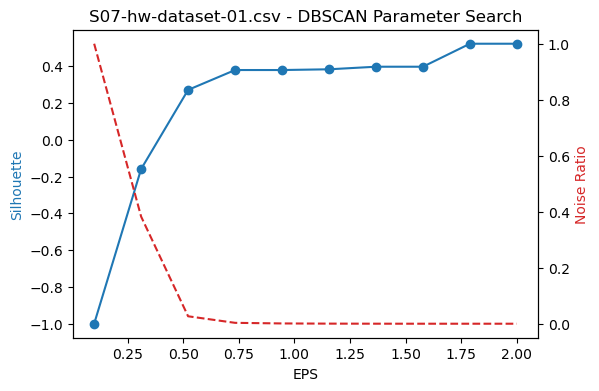

Best DBSCAN params={'eps': 1.788888888888889, 'min_samples': 5} with Sil=0.522
Winner: KMeans (k=2)


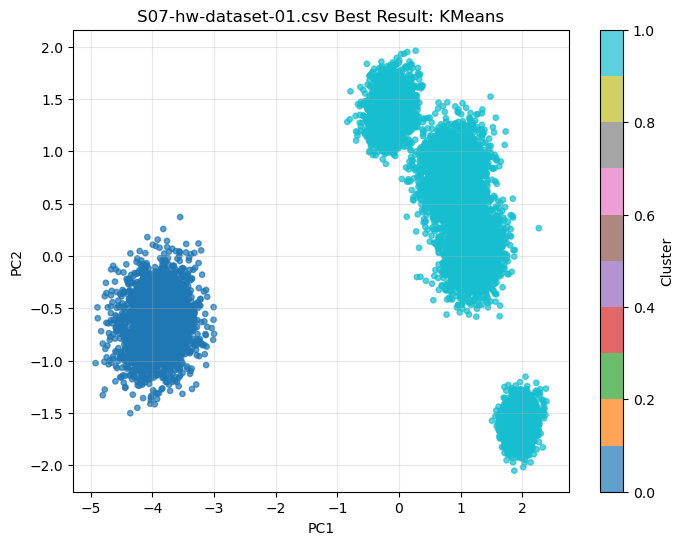


==================== PROCESSING S07-hw-dataset-02.csv ====================

--- EDA: S07-hw-dataset-02.csv ---
Shape: (8000, 4)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB
None
sample_id      int64
x1           float64
x2           float64
z_noise      float64
dtype: object

Missing values:
sample_id    0
x1           0
x2           0
z_noise      0
dtype: int64

Statistics:


,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076



Head:


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472



--- S07-hw-dataset-02.csv: KMeans Experiment ---


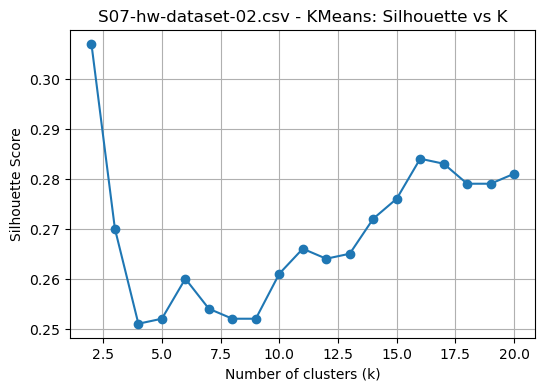

Best KMeans k=2 with Silhouette=0.307

--- S07-hw-dataset-02.csv: DBSCAN Experiment ---


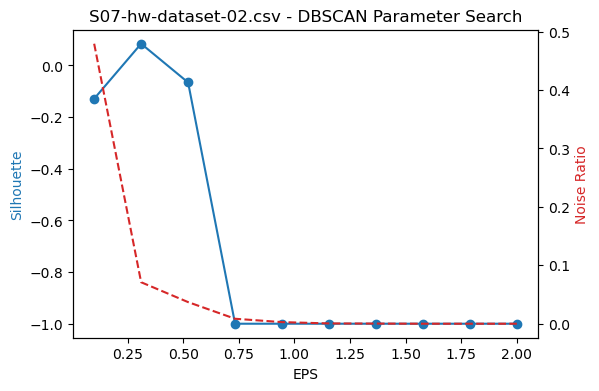

Best DBSCAN params={'eps': 0.3111111111111111, 'min_samples': 5} with Sil=0.084
Winner: KMeans (k=2)


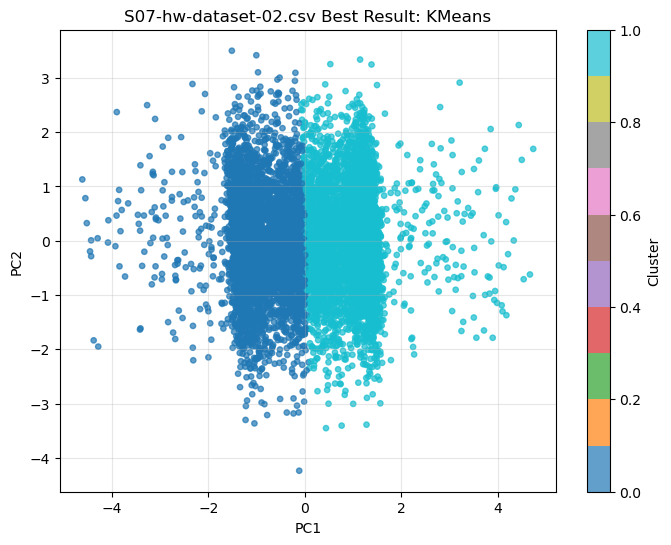


==================== PROCESSING S07-hw-dataset-03.csv ====================

--- EDA: S07-hw-dataset-03.csv ---
Shape: (15000, 5)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB
None
sample_id      int64
x1           float64
x2           float64
f_corr       float64
f_noise      float64
dtype: object

Missing values:
sample_id    0
x1           0
x2           0
f_corr       0
f_noise      0
dtype: int64

Statistics:


,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865



Head:


,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899



--- S07-hw-dataset-03.csv: KMeans Experiment ---


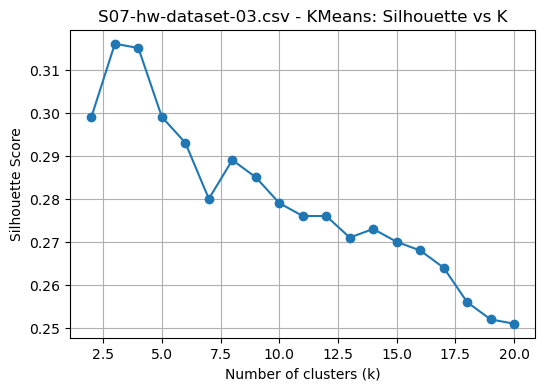

Best KMeans k=3 with Silhouette=0.316

--- S07-hw-dataset-03.csv: DBSCAN Experiment ---


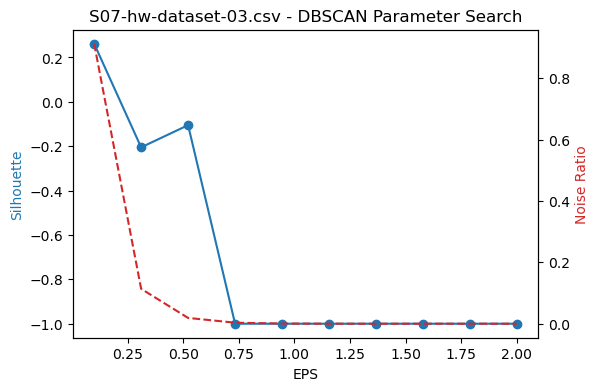

Best DBSCAN params={'eps': 0.1, 'min_samples': 5} with Sil=0.262
Winner: KMeans (k=3)


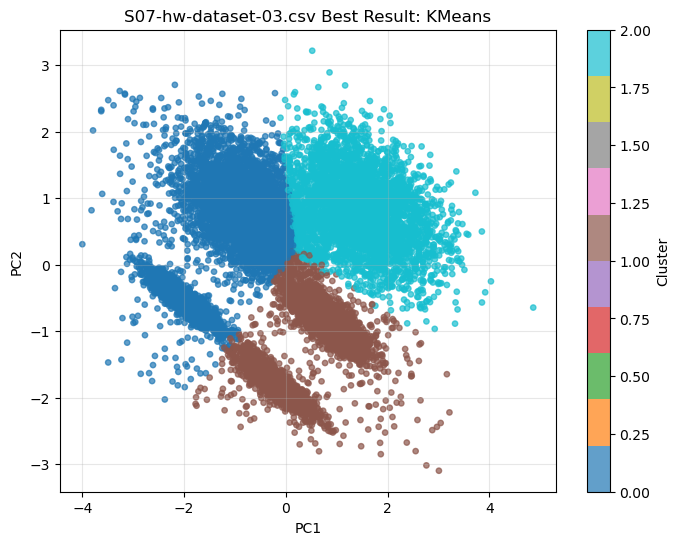

In [4]:
for ds_name in DATASETS:
    print(f"\n{'='*20} PROCESSING {ds_name} {'='*20}")
    
    df, X, sample_id = load_data(ds_name)
    if df is None: continue
    
    basic_eda(df, ds_name)
    preprocessor = get_preprocessor(X)
    X_scaled = preprocessor.fit_transform(X)
    METRICS_SUMMARY[ds_name] = {}
    
    # KMeans
    print(f"\n--- {ds_name}: KMeans Experiment ---")
    k_values = range(2, 21)
    sil_scores = []
    kmeans_results = []
    
    best_kmeans_score = -1
    best_kmeans_k = 2
    best_kmeans_labels = []
    
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        metrics = calculate_internal_metrics(X_scaled, labels)
        
        sil_scores.append(metrics['silhouette'])
        
        kmeans_results.append({"k": k,**metrics})
        
        if metrics['silhouette'] > best_kmeans_score:
            best_kmeans_score = metrics['silhouette']
            best_kmeans_k = k
            best_kmeans_labels = labels

    METRICS_SUMMARY[ds_name]['KMeans'] = kmeans_results
    
    plt.figure(figsize=(6, 4))
    plt.plot(k_values, sil_scores, marker='o')
    plt.title(f"{ds_name} - KMeans: Silhouette vs K")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.savefig(os.path.join(FIGURES_DIR, f"kmeans_sil_{ds_name}.png"))
    plt.show()
    
    print(f"Best KMeans k={best_kmeans_k} with Silhouette={best_kmeans_score}")

    # DBSCAN 
    print(f"\n--- {ds_name}: DBSCAN Experiment ---")
    
    eps_values = np.linspace(0.1, 2.0, 10)
    dbscan_results = []
    
    best_dbscan_score = -1
    best_dbscan_params = {}
    best_dbscan_labels = []
    
    db_sil_scores = []
    db_noise_ratios = []
    
    for eps in eps_values:
        ms = 5 
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        
        metrics = calculate_internal_metrics(X_scaled, labels)
        noise_ratio = np.sum(labels == -1) / len(labels)
        
        dbscan_results.append({"eps": round(eps, 2), "min_samples": ms, "noise_ratio": round(noise_ratio, 2), **metrics})
        
        db_sil_scores.append(metrics['silhouette'])
        db_noise_ratios.append(noise_ratio)

        if metrics['silhouette'] > best_dbscan_score and metrics['silhouette'] != -1:
            best_dbscan_score = metrics['silhouette']
            best_dbscan_params = {"eps": eps, "min_samples": ms}
            best_dbscan_labels = labels

    METRICS_SUMMARY[ds_name]['DBSCAN'] = dbscan_results
    
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ax1.set_xlabel('EPS')
    ax1.set_ylabel('Silhouette', color='tab:blue')
    ax1.plot(eps_values, db_sil_scores, color='tab:blue', marker='o')
    
    ax2 = ax1.twinx()
    ax2.set_ylabel('Noise Ratio', color='tab:red')
    ax2.plot(eps_values, db_noise_ratios, color='tab:red', linestyle='--')
    plt.title(f"{ds_name} - DBSCAN Parameter Search")
    plt.savefig(os.path.join(FIGURES_DIR, f"dbscan_param_{ds_name}.png"))
    plt.show()
    
    print(f"Best DBSCAN params={best_dbscan_params} with Sil={best_dbscan_score}")

    if best_kmeans_score >= best_dbscan_score:
        final_algo = "KMeans"
        final_labels = best_kmeans_labels
        final_params = {"k": best_kmeans_k}
        print(f"Winner: KMeans (k={best_kmeans_k})")
    else:
        final_algo = "DBSCAN"
        final_labels = best_dbscan_labels
        final_params = best_dbscan_params
        print(f"Winner: DBSCAN (eps={best_dbscan_params.get('eps'):.2f})")
    
    BEST_CONFIGS[ds_name] = {
        "algorithm": final_algo,
        "params": final_params,
        "score": max(best_kmeans_score, best_dbscan_score)
    }

    visualize_pca(X_scaled, final_labels, 
                  f"{ds_name} Best Result: {final_algo}", 
                  ds_name.replace(".csv", ""))
    
    labels_df = pd.DataFrame({'sample_id': sample_id, 'cluster_label': final_labels})
    labels_path = os.path.join(LABELS_DIR, f"labels_{ds_name}")
    labels_df.to_csv(labels_path, index=False)


In [5]:
stable_ds = DATASETS[0]
print(f"\n{'='*20} STABILITY CHECK: {stable_ds} {'='*20}")

df_s, X_s, _ = load_data(stable_ds)
X_s_scaled = get_preprocessor(X_s).fit_transform(X_s)

k_stable = BEST_CONFIGS[stable_ds]['params'].get('k', 3) 
if BEST_CONFIGS[stable_ds]['algorithm'] != 'KMeans':
    k_stable = 3

print(f"Checking KMeans stability with k={k_stable} over 5 runs...")

labels_runs = []
for seed in [10, 20, 30, 40, 50]:
    km = KMeans(n_clusters=k_stable, random_state=seed, n_init=1)
    labels_runs.append(km.fit_predict(X_s_scaled))

aris = []
for i in range(len(labels_runs)-1):
    ari = adjusted_rand_score(labels_runs[i], labels_runs[i+1])
    aris.append(ari)
    print(f"Run {i} vs Run {i+1}: ARI = {ari:.4f}")

mean_ari = np.mean(aris)
print(f"Mean ARI: {mean_ari:.4f}. Result is {'Stable' if mean_ari > 0.9 else 'Unstable'}")



==================== STABILITY CHECK: S07-hw-dataset-01.csv ====================
Checking KMeans stability with k=2 over 5 runs...
Run 0 vs Run 1: ARI = 1.0000
Run 1 vs Run 2: ARI = 1.0000
Run 2 vs Run 3: ARI = 1.0000
Run 3 vs Run 4: ARI = 1.0000
Mean ARI: 1.0000. Result is Stable


**Датасет S07-hw-dataset-01.csv** 

В данном эксперименте удалось достичь четкого разделения на 2 кластера с высоким коэффициентом силуэта (0.522). Основная сложность заключалась в существенно разных шкалах признаков: если признаки f03 и f08 имеют малую дисперсию (std ~0.5), то f02, f04 и f07 измеряются десятками и сотнями, что делает предварительное масштабирование критически важным. Пропуски в данных отсутствовали, а структура оказалась близка к сферической, из-за чего KMeans показал себя как наиболее уместный и стабильный метод. Он обеспечил тот же уровень качества, что и DBSCAN, но при меньшей вычислительной сложности и более простой интерпретации центроидов.

**Датасет S07-hw-dataset-02.csv** 

Для этого датасета была характерна работа с низким качеством разделения, где лучший показатель силуэта составил всего 0.307 при k=2. Сложность заключалась в наличии признака z_noise с огромным стандартным отклонением (8.09) по сравнению с основными координатами x1 и x2 (std < 1.0), что создавало сильный фоновый шум и размывало границы групп. Несмотря на нелинейный потенциал данных, DBSCAN показал крайне низкий силуэт (0.084), так как не смог эффективно отделить шум от плотных ядер при заданных параметрах. В итоге KMeans был выбран как уместный вариант, поскольку он смог провести хотя бы грубое геометрическое разделение выборки на две части, что является лучшим результатом в условиях зашумленности.

**Датасет S07-hw-dataset-03.csv** 

В самом крупном датасете (15 000 строк) оптимальным решением стала кластеризация на 3 группы. Главным вызовом стала неоднородность признаков: наличие шумового столбца f_noise и коррелированного признака f_corr затрудняло поиск чистых плотностных структур. Трудности также были связаны с высокой размерностью и объемом данных, что делало подбор параметров eps для DBSCAN чувствительным процессом (лучший результат 0.262). Метод KMeans оказался более уместным, так как при k=3 он показал более высокий силуэт (0.316), успешно агрегировав точки в устойчивые группы, несмотря на наличие фонового шума и разброс значений координат.

In [6]:
with open(os.path.join(ARTIFACTS_DIR, "metrics_summary.json"), "w") as f:
    json.dump(METRICS_SUMMARY, f, indent=4)

with open(os.path.join(ARTIFACTS_DIR, "best_configs.json"), "w") as f:
    json.dump(BEST_CONFIGS, f, indent=4) 
